<a href="https://colab.research.google.com/github/yandexdataschool/nlp_course/blob/2025/resources/_under_construction/25/week_extra/vlm_practice_qwen25_omni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: using multimodal LLMs

In this notebook we deploy and play with Qwen/Qwen2.5-Omni-3B or 7B - a decent small-scale model combining text, audio, image and video inputs with text and audio outputs.

This is a decent (for its size), but not the best model available. If you're choosing the best model for your case, consult thematic leaderbords such as:
* [lmarena.ai/leaderboard](https://lmarena.ai/leaderboard)'s vision section for both proprietary and open-source models,
* [Open VLM Leaderboard](https://huggingface.co/spaces/opencompass/open_vlm_leaderboard) for vision+language models specifically,

As of november-december 2025, popular choices would include:

* [Qwen3 omni](https://huggingface.co/collections/Qwen/qwen3-omni) family, a more recent version or [Qwen3-VL](https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct) for vision-optimized models;
* [PaliGemma family](https://huggingface.co/collections/google/paligemma-release) for broader multilinguality;
* [Kimi-VL-A3B-Thinking-2506](https://huggingface.co/moonshotai/Kimi-VL-A3B-Thinking-2506) (16B) for vision + reasoning.
* [BAGEL-7B-MoT](https://huggingface.co/ByteDance-Seed/BAGEL-7B-MoT) for image generation with LLMs.

You can also find a tutorial for fine-tuning VLMs in colab: [finetune_paigemma.ipynb](https://colab.research.google.com/github/google-research/big_vision/blob/main/big_vision/configs/proj/paligemma/finetune_paligemma.ipynb)

*[Special thanks to [Asya Fadeeva](https://scholar.google.com/citations?user=SodvsocAAAAJ) and [Denis Kuznedelev](https://scholar.google.com/citations?user=L78B2lcAAAAJn) for their help in preparing this demo]*

In [ ]:
!pip install accelerate==0.32.1 transformers==4.57.3 bitsandbytes==0.48.2 qwen-omni-utils[decord]==0.0.8
# colab might ask you to restart session after installing this. If it does - please restart it as requested.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.1/314.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 49.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
  Attempting uninstall: accelerate
  

In [ ]:
%env HF_HUB_DISABLE_XET=1
import torch
import transformers
from qwen_omni_utils import process_mm_info
from IPython.display import display, Audio, Image
MODEL_NAME = "Qwen/Qwen2.5-Omni-3B"  # or change to -7B with quantization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformers.Qwen2_5OmniForConditionalGeneration.from_pretrained(  # if it can't download in 15min, restart session
    MODEL_NAME, torch_dtype="auto", device_map="auto", low_cpu_mem_usage=True,
    quantization_config=None if MODEL_NAME.endswith("3B") else transformers.BitsAndBytesConfig(load_in_4bit=True)
)
processor = transformers.Qwen2_5OmniProcessor.from_pretrained(MODEL_NAME, max_pixels=640 * 480)  # vary max image size to fit into GPU memory
SYSTEM_MESSAGE = {"role": "system", "content": [{"type": "text", "text": "You are Qwen, a virtual human developed by the Qwen Team, Alibaba Group, capable of perceiving auditory and visual inputs, as well as generating text and speech."}],}

env: HF_HUB_DISABLE_XET=1


`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [ ]:
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/dikiy_ogurec.jpg -O img.jpg

conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "image", "image": "./img.jpg"},  # image will be resized, see max_pixels above
    {"type": "text", "text": "What on Earth is this?"}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)
from IPython.display import display, Audio, Image
speaker = "Chelsie"  # or "Ethan" for male voice. Specific to Qwen2.5 Omni
text_ids, audio = model.generate(**inputs, speaker=speaker, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text, = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
display(Image("img.jpg"))
print(*text)  # note: if the model says it's a durian, don't trust it!
display(Audio(data=audio.reshape(-1).detach().cpu().numpy(), rate=24000,))

# Audio input and output

In [ ]:
!wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_DL/491c333ae84340677514a06af153d7dd5c55abd7/week10_speech/sample1.wav -O ./sound.wav

conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "text", "text": "Transcribe the spoken phrase in English, Spanish and French."},
    {"type": "audio", "audio": "sound.wav"}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)

text_ids, audio = model.generate(**inputs, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
display(Audio("./sound.wav"))
display(Audio(data=audio.reshape(-1).detach().cpu().numpy(), rate=24000,))
print(*text)

Setting `pad_token_id` to `eos_token_id`:8292 for open-end generation.


English: That's no moon. It's a space station. Spanish: Eso no es una luna. Es una estación espacial. French: Ce n'est pas une lune. C'est une station spatiale. If you want to know more about translating other phrases, feel free to ask.


In [ ]:
model.disable_talker()  # disable speech module to save GPU time/memory on harder queries
# WARNING: the cells above will not work with talker disabled!

### Multiple images

Well, from what I can see, the first image with the Godzilla statue is definitely larger. It takes up a much bigger portion of the frame. The second image with the gorilla and the woman is smaller in comparison. So, the first one is larger. What do you think? Do you have any other images you want to compare?


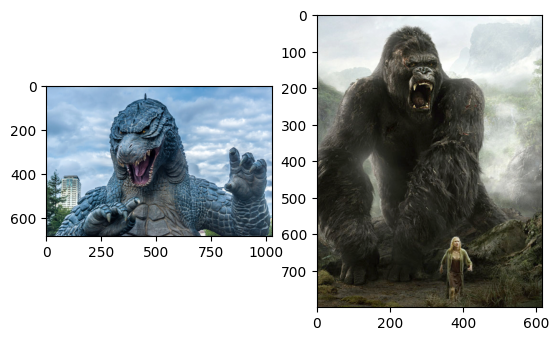

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/godzilla.jpg -O img_A.jpg
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/king-kong-movie.jpg -O img_B.jpg
conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "image", "image": "./img_A.jpg"},
    {"type": "image", "image": "./img_B.jpg"},
    {"type": "text", "text": "Which one is larger?"}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)
text_ids = model.generate(**inputs, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(*text)
plt.subplot(121); plt.imshow(plt.imread("img_A.jpg"))
plt.subplot(122); plt.imshow(plt.imread("img_B.jpg"))

### Playground - upload your own image and prompt

**Note:** The code is currently wired to work on a single image - use the conversation formatting from the examples above to modify it as you see fit. You can also find Qwen2.5 Omni [documentation here](https://huggingface.co/docs/transformers/en/model_doc/qwen2_5_omni).

Saving 2025-12-04-165443.jpg to ./uploaded/2025-12-04-165443 (2).jpg


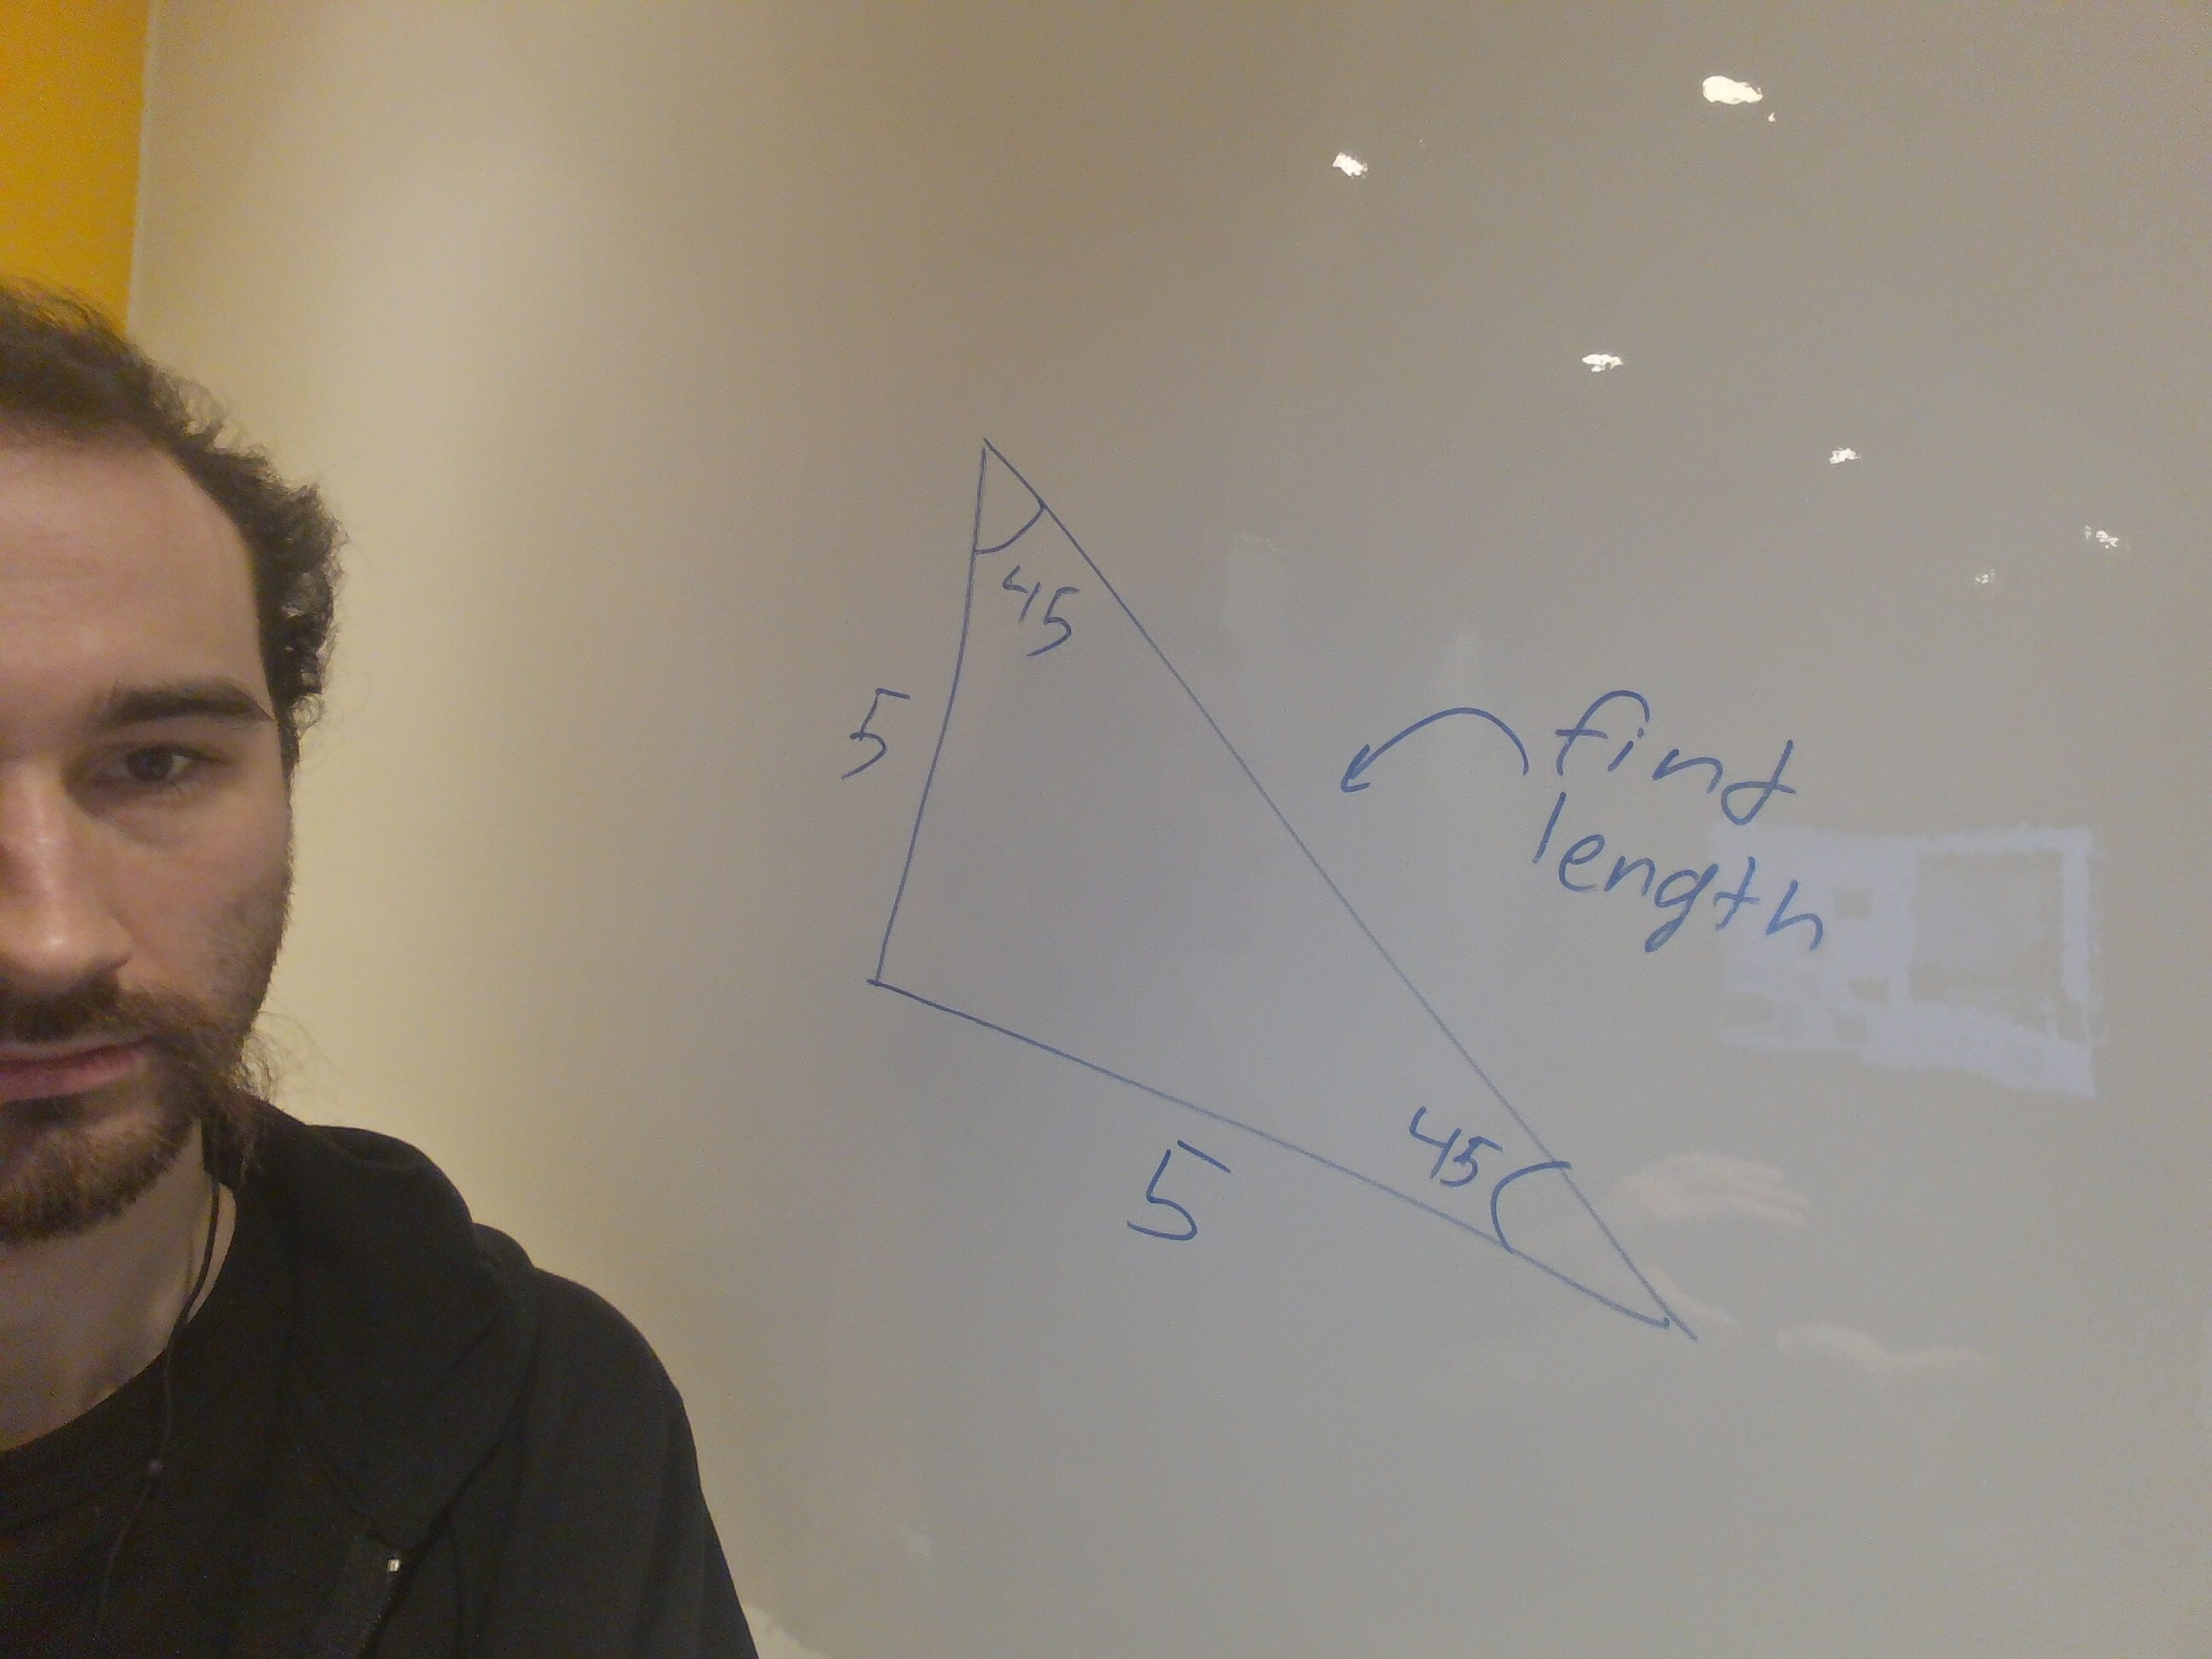

Well, in a right - angled triangle, the longest side is the hypotenuse. Since you've got two sides of length 5 and the angle between them is 45 degrees, this is a special case. It's a 45 - 45 - 90 triangle. In such a triangle, the hypotenuse is equal to the length of one of the legs multiplied by the square root of 2. So, the length of the hypotenuse would be 5 times the square root of 2. That's about 7.07. If you want to know more about triangles or have other questions, feel free to ask.


In [ ]:
from google.colab import files
user_prompt = "Find the length of the longest side in the triangle."  #<TODO write a prompt string>  # in-class demo: Find the length of the longest side in the triangle.
uploaded = files.upload("./uploaded/") # Upload your own file
image_path = next(iter(uploaded.keys()))

conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "image", "image": image_path},  # image will be resized, see max_pixels above
    {"type": "text", "text": user_prompt}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)
text_ids = model.generate(**inputs, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
display(Image(image_path, height=320))
print(*text)